# 📊 INTELIPS: Baseline Models (Experiments 1-3)

This notebook implements the three baseline experiments required for A-grade:

1. **Experiment 1: Metadata-Only Baseline**
   - Logistic Regression
   - Random Forest
   - Features: recipient_count, subject_length, body_length, hour, day_of_week, workload_state, time_segment

2. **Experiment 2: Text-Only Baseline**
   - Naive Bayes
   - SVM (linear kernel)
   - Features: TF-IDF vectors from subject + body (5000 features)

3. **Experiment 3: Combined Baseline**
   - XGBoost
   - Features: TF-IDF + all metadata

All models evaluated with **5-fold stratified cross-validation** as required by grade contract.

## 📚 Setup & Imports

In [4]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import time
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

# XGBoost
try:
    import xgboost as xgb
    print("✅ XGBoost imported successfully")
except ImportError:
    print("⚠️  XGBoost not installed. Installing now...")
    !pip install xgboost
    import xgboost as xgb

# Custom experiment logger
from experiment_logger import ExperimentLogger, calculate_cv_metrics

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ All imports successful!")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ XGBoost imported successfully
✅ All imports successful!
Timestamp: 2025-11-21 18:07:54


## 📁 Load Dataset

In [7]:
# Load the 5,000-email A-grade dataset
print("=" * 80)
print("LOADING A-GRADE DATASET")
print("=" * 80)

df = pd.read_csv('../data/processed/enron_annotated_5000.csv')

print(f"\n✅ Loaded {len(df):,} emails")
print(f"   Columns: {len(df.columns)}")
print(f"   Features: {list(df.columns)}")

# Check priority distribution
print(f"\n📊 Priority Distribution:")
priority_counts = df['priority'].value_counts().sort_index()
for priority, count in priority_counts.items():
    pct = (count / len(df)) * 100
    label = {1: 'Low', 2: 'Normal', 3: 'Critical'}[priority]
    print(f"   {label:8s} ({priority}): {count:4d} ({pct:4.1f}%)")

# Display first few rows
print(f"\n📄 Sample Data:")
display(df.head())

print(f"\n✅ Dataset ready for modeling!")

LOADING A-GRADE DATASET

✅ Loaded 5,000 emails
   Columns: 17
   Features: ['file', 'datetime', 'from', 'to', 'subject', 'body', 'hour', 'day_of_week', 'subject_length', 'body_length', 'recipient_count', 'has_urgency_in_subject', 'has_urgency_in_body', 'workload_state', 'time_segment', 'priority', 'priority_reasoning']

📊 Priority Distribution:
   Low      (1): 2645 (52.9%)
   Normal   (2): 2104 (42.1%)
   Critical (3):  251 ( 5.0%)

📄 Sample Data:


,file,datetime,from,to,subject,body,hour,day_of_week,subject_length,body_length,recipient_count,has_urgency_in_subject,has_urgency_in_body,workload_state,time_segment,priority,priority_reasoning
0,arnold-j/discussion_threads/206.,2000-12-13 17:15:00+00:00,slafontaine@globalp.com,slafontaine@globalp.com,re:spreads,mkt getting a little more bearish the back of ...,17,2,10,241,1,False,False,busy,afternoon,1,The email is a casual market commentary with n...
1,arnold-j/sent/133.,2000-10-09 11:23:00+00:00,john.arnold@enron.com,jennifer.burns@enron.com,Re: Hmmmmm........,"Yea, I'm picking up 2 tix today....hopefully.\...",11,0,18,503,1,False,False,busy,morning,2,The email is a casual request for additional t...
2,arnold-j/sent/405.,2001-05-13 16:16:00+00:00,john.arnold@enron.com,epao@mba2002.hbs.edu,Re: waiting,Expected value of game = 1/2 * 0 + 1/4 * 1 + 1...,16,6,11,900,1,False,False,quiet,afternoon,2,The email asks a question about a game’s expec...
3,arnold-j/deleted_items/147.,2001-10-04 16:11:39+00:00,kathy.mayfield@enron.com,NaN,United Way Young Leaders,As an Enron employee who is a member of the Un...,16,3,24,604,0,False,True,very_busy,afternoon,1,The email is an event invitation with a RSVP d...
4,allen-p/inbox/10.,2001-12-31 06:49:42+00:00,anchordesk_daily@anchordesk.zdlists.com,pallen@enron.com,ANCHORDESK: Hope ahead: What I learned from 20...,\n\n_____________________DAVID COURSEY________...,6,0,60,3827,1,False,True,quiet,morning,1,The email is purely informational/promotional ...



✅ Dataset ready for modeling!


## 🔧 Feature Engineering

We'll prepare three feature sets:
1. **Metadata features** (for Experiment 1)
2. **Text features** (for Experiment 2)
3. **Combined features** (for Experiment 3)

In [8]:
print("=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

# ============================================================================
# 1. METADATA FEATURES (Experiment 1)
# ============================================================================

print("\n📊 Preparing Metadata Features...")

# Numerical features (already clean)
numerical_features = ['recipient_count', 'subject_length', 'body_length', 'hour', 'day_of_week']

# Categorical features (need encoding)
categorical_features = ['workload_state', 'time_segment']

# Boolean features (convert to int)
boolean_features = ['has_urgency_in_subject', 'has_urgency_in_body']

# Create metadata dataframe
X_metadata = df[numerical_features + categorical_features + boolean_features].copy()

# Encode categorical features
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X_metadata[col] = le.fit_transform(X_metadata[col])
    label_encoders[col] = le
    print(f"   Encoded {col}: {len(le.classes_)} classes")

# Convert boolean to int
for col in boolean_features:
    X_metadata[col] = X_metadata[col].astype(int)

print(f"\n✅ Metadata features: {X_metadata.shape[1]} features")
print(f"   Feature names: {list(X_metadata.columns)}")

# ============================================================================
# 2. TEXT FEATURES (Experiment 2)
# ============================================================================

print("\n📝 Preparing Text Features (TF-IDF)...")

# Combine subject and body
df['text_combined'] = df['subject'].fillna('') + ' ' + df['body'].fillna('')

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    stop_words='english'
)

# Fit and transform
X_text_tfidf = tfidf_vectorizer.fit_transform(df['text_combined'])

print(f"\n✅ Text features (TF-IDF): {X_text_tfidf.shape[1]} features")
print(f"   Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"   Sparsity: {(1 - X_text_tfidf.nnz / (X_text_tfidf.shape[0] * X_text_tfidf.shape[1])) * 100:.2f}%")

# ============================================================================
# 3. COMBINED FEATURES (Experiment 3)
# ============================================================================

print("\n🔗 Preparing Combined Features (TF-IDF + Metadata)...")

# Standardize metadata features for combination
scaler = StandardScaler()
X_metadata_scaled = scaler.fit_transform(X_metadata)

# Combine TF-IDF and metadata (as dense for XGBoost)
from scipy.sparse import hstack, csr_matrix
X_combined_sparse = hstack([X_text_tfidf, csr_matrix(X_metadata_scaled)])
X_combined = X_combined_sparse.toarray()  # XGBoost works better with dense

print(f"\n✅ Combined features: {X_combined.shape[1]} features")
print(f"   TF-IDF: {X_text_tfidf.shape[1]} + Metadata: {X_metadata_scaled.shape[1]}")

# ============================================================================
# Target variable
# ============================================================================

y = df['priority'].values

print(f"\n✅ Target variable: {len(y)} samples")
print(f"   Classes: {np.unique(y)}")
print(f"\n" + "=" * 80)
print("✅ ALL FEATURES READY FOR MODELING!")
print("=" * 80)

FEATURE ENGINEERING

📊 Preparing Metadata Features...
   Encoded workload_state: 4 classes
   Encoded time_segment: 4 classes

✅ Metadata features: 9 features
   Feature names: ['recipient_count', 'subject_length', 'body_length', 'hour', 'day_of_week', 'workload_state', 'time_segment', 'has_urgency_in_subject', 'has_urgency_in_body']

📝 Preparing Text Features (TF-IDF)...

✅ Text features (TF-IDF): 5000 features
   Vocabulary size: 5000
   Sparsity: 98.14%

🔗 Preparing Combined Features (TF-IDF + Metadata)...

✅ Combined features: 5009 features
   TF-IDF: 5000 + Metadata: 9

✅ Target variable: 5000 samples
   Classes: [1 2 3]

✅ ALL FEATURES READY FOR MODELING!


## 🎯 Cross-Validation Setup

We'll use **5-fold stratified cross-validation** as required by the grade contract.

In [9]:
# Setup 5-fold stratified CV
n_folds = 5
cv_splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

print(f"✅ Cross-validation setup:")
print(f"   Folds: {n_folds}")
print(f"   Strategy: Stratified (maintains class distribution)")
print(f"   Random seed: 42")

# Initialize experiment logger
logger = ExperimentLogger(log_dir='results')
print(f"\n✅ Experiment logger initialized")
print(f"   Results will be saved to: results/all_experiments.json")

✅ Cross-validation setup:
   Folds: 5
   Strategy: Stratified (maintains class distribution)
   Random seed: 42

✅ Experiment logger initialized
   Results will be saved to: results/all_experiments.json


---

# 🔵 EXPERIMENT 1: Metadata-Only Baseline

**Goal:** Establish baseline performance using ONLY metadata features (no text).

**Features:** recipient_count, subject_length, body_length, hour, day_of_week, workload_state, time_segment, urgency flags

**Models:**
- Logistic Regression (simple linear baseline)
- Random Forest (non-linear baseline)

## 1A: Logistic Regression (Metadata-Only)

In [10]:
print("=" * 80)
print("EXPERIMENT 1A: LOGISTIC REGRESSION (METADATA-ONLY)")
print("=" * 80)

# Standardize metadata features
scaler_exp1 = StandardScaler()
X_metadata_scaled = scaler_exp1.fit_transform(X_metadata)

# Model setup
model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',  # Handle class imbalance
    multi_class='multinomial',
    solver='lbfgs'
)

# Manual cross-validation to collect predictions
y_true_folds = []
y_pred_folds = []

start_time = time.time()

print("\n⏳ Running 5-fold cross-validation...")
for fold_idx, (train_idx, val_idx) in enumerate(cv_splitter.split(X_metadata_scaled, y), 1):
    # Split data
    X_train, X_val = X_metadata_scaled[train_idx], X_metadata_scaled[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Train
    model_lr.fit(X_train, y_train)
    
    # Predict
    y_pred = model_lr.predict(X_val)
    
    # Store
    y_true_folds.append(y_val)
    y_pred_folds.append(y_pred)
    
    # Fold metrics
    fold_f1 = f1_score(y_val, y_pred, average='macro')
    fold_acc = accuracy_score(y_val, y_pred)
    print(f"   Fold {fold_idx}: Macro F1 = {fold_f1:.4f}, Accuracy = {fold_acc:.4f}")

training_time = time.time() - start_time

# Calculate CV metrics
cv_results_lr = calculate_cv_metrics(y_true_folds, y_pred_folds)

# Log experiment
logger.log_experiment(
    experiment_id='exp_1a_metadata_logistic_regression',
    experiment_name='Experiment 1A: Metadata-Only - Logistic Regression',
    model_type='LogisticRegression',
    features_used=['metadata', 'temporal', 'urgency'],
    hyperparameters={
        'max_iter': 1000,
        'class_weight': 'balanced',
        'multi_class': 'multinomial',
        'solver': 'lbfgs'
    },
    cv_results=cv_results_lr,
    training_time=training_time,
    notes='Baseline using only metadata features (no text). Linear model.'
)

# Print detailed results
print(f"\n" + "=" * 80)
print(f"📊 RESULTS:")
print(f"   Macro F1:     {cv_results_lr['macro_f1_mean']:.4f} ± {cv_results_lr['macro_f1_std']:.4f}")
print(f"   Weighted Acc: {cv_results_lr['weighted_acc_mean']:.4f} ± {cv_results_lr['weighted_acc_std']:.4f}")
print(f"\n   Per-class F1:")
for cls, f1 in cv_results_lr['per_class_f1_mean'].items():
    label = {1: 'Low', 2: 'Normal', 3: 'Critical'}[cls]
    print(f"      {label:8s} ({cls}): {f1:.4f} ± {cv_results_lr['per_class_f1_std'][cls]:.4f}")
print(f"\n   Training time: {training_time:.2f}s")
print("=" * 80)

EXPERIMENT 1A: LOGISTIC REGRESSION (METADATA-ONLY)

⏳ Running 5-fold cross-validation...
   Fold 1: Macro F1 = 0.4007, Accuracy = 0.4760
   Fold 2: Macro F1 = 0.4104, Accuracy = 0.4720
   Fold 3: Macro F1 = 0.4221, Accuracy = 0.4910
   Fold 4: Macro F1 = 0.4353, Accuracy = 0.5030
   Fold 5: Macro F1 = 0.4233, Accuracy = 0.4900

✅ Logged: Experiment 1A: Metadata-Only - Logistic Regression
   Model: LogisticRegression
   Macro F1: 0.4184 ± 0.0118
   Weighted Acc: 0.4864 ± 0.0112
   Training time: 0.05s

📊 RESULTS:
   Macro F1:     0.4184 ± 0.0118
   Weighted Acc: 0.4864 ± 0.0112

   Per-class F1:
      Low      (1): 0.5463 ± 0.0217
      Normal   (2): 0.5034 ± 0.0107
      Critical (3): 0.2054 ± 0.0218

   Training time: 0.05s


## 1B: Random Forest (Metadata-Only)

In [ ]:
print("=" * 80)
print("EXPERIMENT 1B: RANDOM FOREST (METADATA-ONLY)")
print("=" * 80)

# Model setup
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Manual cross-validation
y_true_folds = []
y_pred_folds = []

start_time = time.time()

print("\n⏳ Running 5-fold cross-validation...")
for fold_idx, (train_idx, val_idx) in enumerate(cv_splitter.split(X_metadata, y), 1):
    # Split data (no scaling needed for RF)
    X_train, X_val = X_metadata.iloc[train_idx], X_metadata.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Train
    model_rf.fit(X_train, y_train)
    
    # Predict
    y_pred = model_rf.predict(X_val)
    
    # Store
    y_true_folds.append(y_val)
    y_pred_folds.append(y_pred)
    
    # Fold metrics
    fold_f1 = f1_score(y_val, y_pred, average='macro')
    fold_acc = accuracy_score(y_val, y_pred)
    print(f"   Fold {fold_idx}: Macro F1 = {fold_f1:.4f}, Accuracy = {fold_acc:.4f}")

training_time = time.time() - start_time

# Calculate CV metrics
cv_results_rf = calculate_cv_metrics(y_true_folds, y_pred_folds)

# Log experiment
logger.log_experiment(
    experiment_id='exp_1b_metadata_random_forest',
    experiment_name='Experiment 1B: Metadata-Only - Random Forest',
    model_type='RandomForestClassifier',
    features_used=['metadata', 'temporal', 'urgency'],
    hyperparameters={
        'n_estimators': 100,
        'max_depth': 15,
        'min_samples_split': 10,
        'min_samples_leaf': 4,
        'class_weight': 'balanced'
    },
    cv_results=cv_results_rf,
    training_time=training_time,
    notes='Baseline using only metadata features (no text). Non-linear ensemble model.'
)

# Print detailed results
print(f"\n" + "=" * 80)
print(f"📊 RESULTS:")
print(f"   Macro F1:     {cv_results_rf['macro_f1_mean']:.4f} ± {cv_results_rf['macro_f1_std']:.4f}")
print(f"   Weighted Acc: {cv_results_rf['weighted_acc_mean']:.4f} ± {cv_results_rf['weighted_acc_std']:.4f}")
print(f"\n   Per-class F1:")
for cls, f1 in cv_results_rf['per_class_f1_mean'].items():
    label = {1: 'Low', 2: 'Normal', 3: 'Critical'}[cls]
    print(f"      {label:8s} ({cls}): {f1:.4f} ± {cv_results_rf['per_class_f1_std'][cls]:.4f}")
print(f"\n   Training time: {training_time:.2f}s")
print("=" * 80)

# Feature importance
print(f"\n📊 TOP 10 FEATURE IMPORTANCES:")
# Train final model to get feature importances
model_rf.fit(X_metadata, y)
feature_importances = pd.DataFrame({
    'feature': X_metadata.columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False).head(10)
print(feature_importances.to_string(index=False))

EXPERIMENT 1B: RANDOM FOREST (METADATA-ONLY)

⏳ Running 5-fold cross-validation...
   Fold 1: Macro F1 = 0.5933, Accuracy = 0.6810
   Fold 2: Macro F1 = 0.6072, Accuracy = 0.6710
   Fold 3: Macro F1 = 0.6395, Accuracy = 0.6880
   Fold 4: Macro F1 = 0.6221, Accuracy = 0.6630
   Fold 5: Macro F1 = 0.6248, Accuracy = 0.6780

✅ Logged: Experiment 1B: Metadata-Only - Random Forest
   Model: RandomForestClassifier
   Macro F1: 0.6174 ± 0.0158
   Weighted Acc: 0.6762 ± 0.0086
   Training time: 0.58s

📊 RESULTS:
   Macro F1:     0.6174 ± 0.0158
   Weighted Acc: 0.6762 ± 0.0086

   Per-class F1:
      Low      (1): 0.7262 ± 0.0105
      Normal   (2): 0.6405 ± 0.0135
      Critical (3): 0.4854 ± 0.0530

   Training time: 0.58s

📊 TOP 10 FEATURE IMPORTANCES:
               feature  importance
           body_length    0.330142
        subject_length    0.228433
                  hour    0.124735
           day_of_week    0.100187
   has_urgency_in_body    0.087775
       recipient_count    0.0503

---

# 🟢 EXPERIMENT 2: Text-Only Baseline

**Goal:** Establish baseline performance using ONLY text features (no context).

**Features:** TF-IDF vectors from subject + body (5000 features)

**Models:**
- Naive Bayes (probabilistic baseline)
- Linear SVM (linear text classifier)

## 2A: Naive Bayes (Text-Only)

In [11]:
print("=" * 80)
print("EXPERIMENT 2A: NAIVE BAYES (TEXT-ONLY)")
print("=" * 80)

# Model setup
model_nb = MultinomialNB(alpha=0.1)  # Laplace smoothing

# Manual cross-validation
y_true_folds = []
y_pred_folds = []

start_time = time.time()

print("\n⏳ Running 5-fold cross-validation...")
for fold_idx, (train_idx, val_idx) in enumerate(cv_splitter.split(X_text_tfidf, y), 1):
    # Split data
    X_train, X_val = X_text_tfidf[train_idx], X_text_tfidf[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Train
    model_nb.fit(X_train, y_train)
    
    # Predict
    y_pred = model_nb.predict(X_val)
    
    # Store
    y_true_folds.append(y_val)
    y_pred_folds.append(y_pred)
    
    # Fold metrics
    fold_f1 = f1_score(y_val, y_pred, average='macro')
    fold_acc = accuracy_score(y_val, y_pred)
    print(f"   Fold {fold_idx}: Macro F1 = {fold_f1:.4f}, Accuracy = {fold_acc:.4f}")

training_time = time.time() - start_time

# Calculate CV metrics
cv_results_nb = calculate_cv_metrics(y_true_folds, y_pred_folds)

# Log experiment
logger.log_experiment(
    experiment_id='exp_2a_text_naive_bayes',
    experiment_name='Experiment 2A: Text-Only - Naive Bayes',
    model_type='MultinomialNB',
    features_used=['text_tfidf'],
    hyperparameters={
        'alpha': 0.1,
        'tfidf_max_features': 5000,
        'ngram_range': '(1, 2)'
    },
    cv_results=cv_results_nb,
    training_time=training_time,
    notes='Baseline using only text features (TF-IDF). No context information.'
)

# Print detailed results
print(f"\n" + "=" * 80)
print(f"📊 RESULTS:")
print(f"   Macro F1:     {cv_results_nb['macro_f1_mean']:.4f} ± {cv_results_nb['macro_f1_std']:.4f}")
print(f"   Weighted Acc: {cv_results_nb['weighted_acc_mean']:.4f} ± {cv_results_nb['weighted_acc_std']:.4f}")
print(f"\n   Per-class F1:")
for cls, f1 in cv_results_nb['per_class_f1_mean'].items():
    label = {1: 'Low', 2: 'Normal', 3: 'Critical'}[cls]
    print(f"      {label:8s} ({cls}): {f1:.4f} ± {cv_results_nb['per_class_f1_std'][cls]:.4f}")
print(f"\n   Training time: {training_time:.2f}s")
print("=" * 80)

EXPERIMENT 2A: NAIVE BAYES (TEXT-ONLY)

⏳ Running 5-fold cross-validation...
   Fold 1: Macro F1 = 0.5375, Accuracy = 0.6980
   Fold 2: Macro F1 = 0.5862, Accuracy = 0.6950
   Fold 3: Macro F1 = 0.6047, Accuracy = 0.6900
   Fold 4: Macro F1 = 0.6138, Accuracy = 0.6970
   Fold 5: Macro F1 = 0.6449, Accuracy = 0.7070

✅ Logged: Experiment 2A: Text-Only - Naive Bayes
   Model: MultinomialNB
   Macro F1: 0.5974 ± 0.0354
   Weighted Acc: 0.6974 ± 0.0055
   Training time: 0.02s

📊 RESULTS:
   Macro F1:     0.5974 ± 0.0354
   Weighted Acc: 0.6974 ± 0.0055

   Per-class F1:
      Low      (1): 0.7299 ± 0.0096
      Normal   (2): 0.6934 ± 0.0080
      Critical (3): 0.3690 ± 0.1099

   Training time: 0.02s


## 2B: Linear SVM (Text-Only)

In [12]:
print("=" * 80)
print("EXPERIMENT 2B: LINEAR SVM (TEXT-ONLY)")
print("=" * 80)

# Model setup
model_svm = LinearSVC(
    C=1.0,
    max_iter=2000,
    random_state=42,
    class_weight='balanced'
)

# Manual cross-validation
y_true_folds = []
y_pred_folds = []

start_time = time.time()

print("\n⏳ Running 5-fold cross-validation...")
for fold_idx, (train_idx, val_idx) in enumerate(cv_splitter.split(X_text_tfidf, y), 1):
    # Split data
    X_train, X_val = X_text_tfidf[train_idx], X_text_tfidf[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Train
    model_svm.fit(X_train, y_train)
    
    # Predict
    y_pred = model_svm.predict(X_val)
    
    # Store
    y_true_folds.append(y_val)
    y_pred_folds.append(y_pred)
    
    # Fold metrics
    fold_f1 = f1_score(y_val, y_pred, average='macro')
    fold_acc = accuracy_score(y_val, y_pred)
    print(f"   Fold {fold_idx}: Macro F1 = {fold_f1:.4f}, Accuracy = {fold_acc:.4f}")

training_time = time.time() - start_time

# Calculate CV metrics
cv_results_svm = calculate_cv_metrics(y_true_folds, y_pred_folds)

# Log experiment
logger.log_experiment(
    experiment_id='exp_2b_text_linear_svm',
    experiment_name='Experiment 2B: Text-Only - Linear SVM',
    model_type='LinearSVC',
    features_used=['text_tfidf'],
    hyperparameters={
        'C': 1.0,
        'max_iter': 2000,
        'class_weight': 'balanced',
        'tfidf_max_features': 5000,
        'ngram_range': '(1, 2)'
    },
    cv_results=cv_results_svm,
    training_time=training_time,
    notes='Baseline using only text features (TF-IDF). Linear kernel SVM.'
)

# Print detailed results
print(f"\n" + "=" * 80)
print(f"📊 RESULTS:")
print(f"   Macro F1:     {cv_results_svm['macro_f1_mean']:.4f} ± {cv_results_svm['macro_f1_std']:.4f}")
print(f"   Weighted Acc: {cv_results_svm['weighted_acc_mean']:.4f} ± {cv_results_svm['weighted_acc_std']:.4f}")
print(f"\n   Per-class F1:")
for cls, f1 in cv_results_svm['per_class_f1_mean'].items():
    label = {1: 'Low', 2: 'Normal', 3: 'Critical'}[cls]
    print(f"      {label:8s} ({cls}): {f1:.4f} ± {cv_results_svm['per_class_f1_std'][cls]:.4f}")
print(f"\n   Training time: {training_time:.2f}s")
print("=" * 80)

EXPERIMENT 2B: LINEAR SVM (TEXT-ONLY)

⏳ Running 5-fold cross-validation...
   Fold 1: Macro F1 = 0.6987, Accuracy = 0.7800
   Fold 2: Macro F1 = 0.6790, Accuracy = 0.7380
   Fold 3: Macro F1 = 0.7053, Accuracy = 0.7830
   Fold 4: Macro F1 = 0.7136, Accuracy = 0.7570
   Fold 5: Macro F1 = 0.6933, Accuracy = 0.7580

✅ Logged: Experiment 2B: Text-Only - Linear SVM
   Model: LinearSVC
   Macro F1: 0.6980 ± 0.0117
   Weighted Acc: 0.7632 ± 0.0166
   Training time: 0.36s

📊 RESULTS:
   Macro F1:     0.6980 ± 0.0117
   Weighted Acc: 0.7632 ± 0.0166

   Per-class F1:
      Low      (1): 0.8096 ± 0.0208
      Normal   (2): 0.7330 ± 0.0162
      Critical (3): 0.5514 ± 0.0357

   Training time: 0.36s


---

# 🟡 EXPERIMENT 3: Combined Baseline (XGBoost)

**Goal:** Best traditional ML baseline combining ALL features.

**Features:** TF-IDF (5000) + Metadata (9) = 5009 features

**Model:** XGBoost (state-of-the-art gradient boosting)

In [13]:
print("=" * 80)
print("EXPERIMENT 3: XGBOOST (COMBINED FEATURES)")
print("=" * 80)

# FIX: Remap labels from [1,2,3] to [0,1,2] for XGBoost
y_xgb = y - 1  # Now classes are [0, 1, 2]

# Model setup
model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=-1
)

# Manual cross-validation
y_true_folds = []
y_pred_folds = []

start_time = time.time()

print("\n⏳ Running 5-fold cross-validation...")
for fold_idx, (train_idx, val_idx) in enumerate(cv_splitter.split(X_combined, y_xgb), 1):
    # Split data
    X_train, X_val = X_combined[train_idx], X_combined[val_idx]
    y_train, y_val = y_xgb[train_idx], y_xgb[val_idx]

    # Train
    model_xgb.fit(X_train, y_train, verbose=False)

    # Predict (will be in [0,1,2])
    y_pred_xgb = model_xgb.predict(X_val)

    # Convert back to [1,2,3] for metrics
    y_val_original = y_val + 1
    y_pred_original = y_pred_xgb + 1

    # Store
    y_true_folds.append(y_val_original)
    y_pred_folds.append(y_pred_original)

    # Fold metrics
    fold_f1 = f1_score(y_val_original, y_pred_original, average='macro')
    fold_acc = accuracy_score(y_val_original, y_pred_original)
    print(f"   Fold {fold_idx}: Macro F1 = {fold_f1:.4f}, Accuracy = {fold_acc:.4f}")

training_time = time.time() - start_time

# Calculate CV metrics
cv_results_xgb = calculate_cv_metrics(y_true_folds, y_pred_folds)

# Log experiment
logger.log_experiment(
    experiment_id='exp_3_combined_xgboost',
    experiment_name='Experiment 3: Combined Features - XGBoost',
    model_type='XGBClassifier',
    features_used=['text_tfidf', 'metadata', 'temporal', 'urgency'],
    hyperparameters={
        'n_estimators': 200,
        'max_depth': 7,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'total_features': X_combined.shape[1]
    },
    cv_results=cv_results_xgb,
    training_time=training_time,
    notes='Best traditional ML baseline. Combines TF-IDF text features with all metadata.'
)

# Print detailed results
print(f"\n" + "=" * 80)
print(f"📊 RESULTS:")
print(f"   Macro F1:     {cv_results_xgb['macro_f1_mean']:.4f} ± {cv_results_xgb['macro_f1_std']:.4f}")
print(f"   Weighted Acc: {cv_results_xgb['weighted_acc_mean']:.4f} ± {cv_results_xgb['weighted_acc_std']:.4f}")
print(f"\n   Per-class F1:")
for cls, f1 in cv_results_xgb['per_class_f1_mean'].items():
    label = {1: 'Low', 2: 'Normal', 3: 'Critical'}[cls]
    print(f"      {label:8s} ({cls}): {f1:.4f} ± {cv_results_xgb['per_class_f1_std'][cls]:.4f}")
print(f"\n   Training time: {training_time:.2f}s")
print("=" * 80)

EXPERIMENT 3: XGBOOST (COMBINED FEATURES)

⏳ Running 5-fold cross-validation...
   Fold 1: Macro F1 = 0.6884, Accuracy = 0.8040
   Fold 2: Macro F1 = 0.7232, Accuracy = 0.7880
   Fold 3: Macro F1 = 0.7423, Accuracy = 0.8050
   Fold 4: Macro F1 = 0.7579, Accuracy = 0.8090
   Fold 5: Macro F1 = 0.6970, Accuracy = 0.7790

✅ Logged: Experiment 3: Combined Features - XGBoost
   Model: XGBClassifier
   Macro F1: 0.7218 ± 0.0263
   Weighted Acc: 0.7970 ± 0.0115
   Training time: 84.55s

📊 RESULTS:
   Macro F1:     0.7218 ± 0.0263
   Weighted Acc: 0.7970 ± 0.0115

   Per-class F1:
      Low      (1): 0.8394 ± 0.0103
      Normal   (2): 0.7659 ± 0.0126
      Critical (3): 0.5600 ± 0.0756

   Training time: 84.55s


---

# 📊 BASELINE EXPERIMENTS SUMMARY

In [14]:
# Print comprehensive summary
logger.print_summary()

# Export comparison table
comparison_df = logger.export_comparison_table('baseline_comparison.csv')

print("\n" + "=" * 80)
print("📊 BASELINE MODELS COMPARISON")
print("=" * 80)
display(comparison_df)

# Get best baseline model
best_model = logger.get_best_model(metric='macro_f1_mean')


EXPERIMENT SUMMARY

Experiment 1A: Metadata-Only - Logistic Regression
  ID: exp_1a_metadata_logistic_regression
  Model: LogisticRegression
  Features: metadata, temporal, urgency
  Results:
    Macro F1:     0.4184 ± 0.0118
    Weighted Acc: 0.4864 ± 0.0112
    Per-class F1:
      Class 1: 0.5463
      Class 2: 0.5034
      Class 3: 0.2054
  Training time: 0.05s
  Timestamp: 2025-11-21T18:09:16.890209
  Notes: Baseline using only metadata features (no text). Linear model.

Experiment 2A: Text-Only - Naive Bayes
  ID: exp_2a_text_naive_bayes
  Model: MultinomialNB
  Features: text_tfidf
  Results:
    Macro F1:     0.5974 ± 0.0354
    Weighted Acc: 0.6974 ± 0.0055
    Per-class F1:
      Class 1: 0.7299
      Class 2: 0.6934
      Class 3: 0.3690
  Training time: 0.02s
  Timestamp: 2025-11-21T18:09:23.927905
  Notes: Baseline using only text features (TF-IDF). No context information.

Experiment 2B: Text-Only - Linear SVM
  ID: exp_2b_text_linear_svm
  Model: LinearSVC
  Features: te

,Experiment,Model,Features,Macro F1,Weighted Acc,Training Time (s),F1 Class 1,F1 Class 2,F1 Class 3
0,Experiment 1A: Metadata-Only - Logistic Regres...,LogisticRegression,"metadata, temporal, urgency",0.4184 ± 0.0118,0.4864 ± 0.0112,0.05,0.5463,0.5034,0.2054
1,Experiment 2A: Text-Only - Naive Bayes,MultinomialNB,text_tfidf,0.5974 ± 0.0354,0.6974 ± 0.0055,0.02,0.7299,0.6934,0.3690
2,Experiment 2B: Text-Only - Linear SVM,LinearSVC,text_tfidf,0.6980 ± 0.0117,0.7632 ± 0.0166,0.36,0.8096,0.7330,0.5514
3,Experiment 3: Combined Features - XGBoost,XGBClassifier,"text_tfidf, metadata, temporal, urgency",0.7218 ± 0.0263,0.7970 ± 0.0115,84.55,0.8394,0.7659,0.5600



🏆 BEST MODEL (by macro_f1_mean):
   Experiment 3: Combined Features - XGBoost
   macro_f1_mean: 0.7218


## 📈 Visualize Results


✅ Saved figure: results/baseline_models_comparison.png


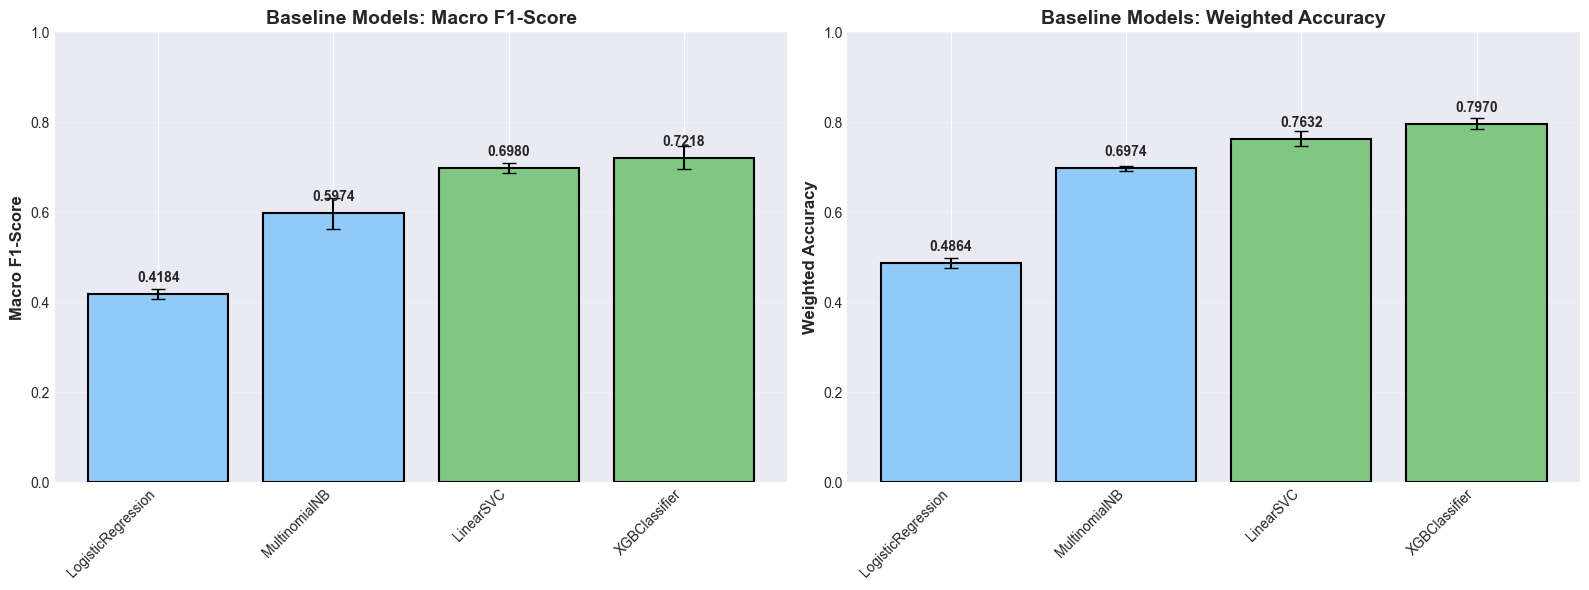

In [15]:
# Create visualization of baseline results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Get all baseline experiments
experiments = logger.get_all_experiments()

# Extract data
exp_names = [exp['model_type'] for exp in experiments]
macro_f1_means = [exp['cv_results']['macro_f1_mean'] for exp in experiments]
macro_f1_stds = [exp['cv_results']['macro_f1_std'] for exp in experiments]
weighted_acc_means = [exp['cv_results']['weighted_acc_mean'] for exp in experiments]
weighted_acc_stds = [exp['cv_results']['weighted_acc_std'] for exp in experiments]

# Colors based on experiment type
colors = ['#90CAF9', '#90CAF9',  # Metadata-only (blue)
          '#81C784', '#81C784',  # Text-only (green)
          '#FFD54F']             # Combined (yellow)

# Plot 1: Macro F1 scores
ax1 = axes[0]
bars1 = ax1.bar(range(len(exp_names)), macro_f1_means, yerr=macro_f1_stds,
                color=colors, capsize=5, edgecolor='black', linewidth=1.5)
ax1.set_xticks(range(len(exp_names)))
ax1.set_xticklabels(exp_names, rotation=45, ha='right')
ax1.set_ylabel('Macro F1-Score', fontsize=12, fontweight='bold')
ax1.set_title('Baseline Models: Macro F1-Score', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars1, macro_f1_means):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Weighted Accuracy
ax2 = axes[1]
bars2 = ax2.bar(range(len(exp_names)), weighted_acc_means, yerr=weighted_acc_stds,
                color=colors, capsize=5, edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(exp_names)))
ax2.set_xticklabels(exp_names, rotation=45, ha='right')
ax2.set_ylabel('Weighted Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Baseline Models: Weighted Accuracy', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1.0)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars2, weighted_acc_means):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('results/baseline_models_comparison.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved figure: results/baseline_models_comparison.png")
plt.show()

## 🎯 Per-Class Performance Visualization


✅ Saved figure: results/baseline_per_class_f1.png


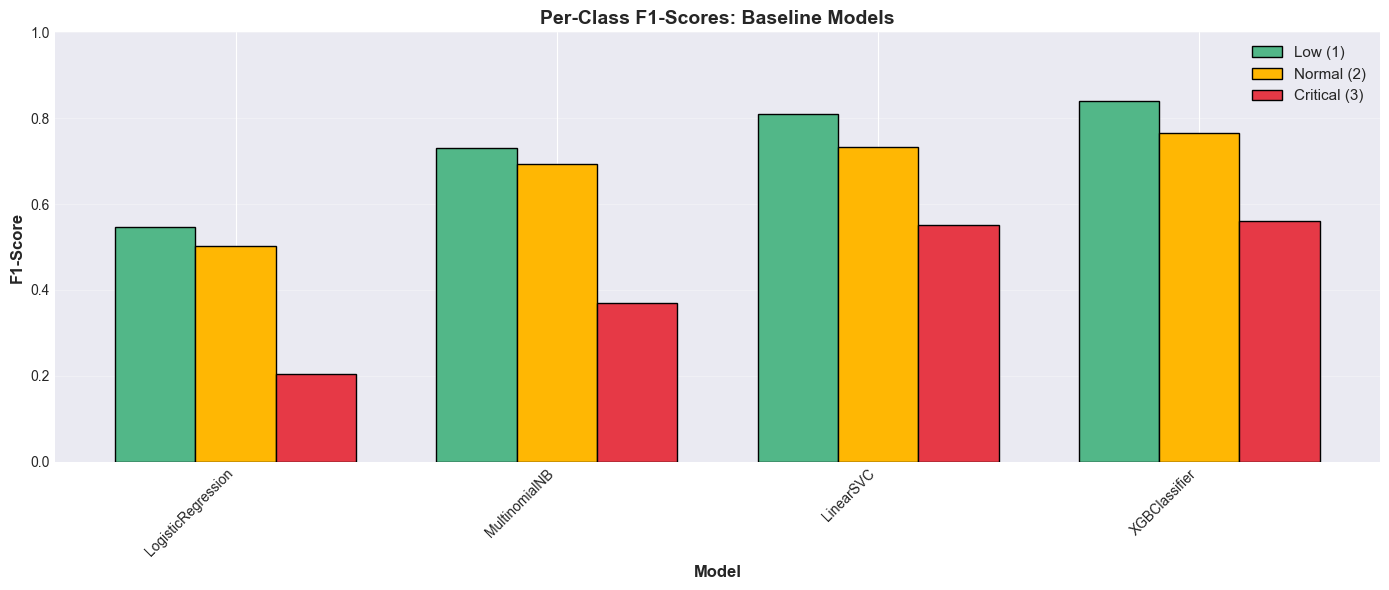

In [16]:
# Per-class F1 scores visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data
x = np.arange(len(exp_names))
width = 0.25

class_1_f1 = [exp['cv_results']['per_class_f1_mean'][1] for exp in experiments]
class_2_f1 = [exp['cv_results']['per_class_f1_mean'][2] for exp in experiments]
class_3_f1 = [exp['cv_results']['per_class_f1_mean'][3] for exp in experiments]

# Plot bars
bars1 = ax.bar(x - width, class_1_f1, width, label='Low (1)', color='#52B788', edgecolor='black')
bars2 = ax.bar(x, class_2_f1, width, label='Normal (2)', color='#FFB703', edgecolor='black')
bars3 = ax.bar(x + width, class_3_f1, width, label='Critical (3)', color='#E63946', edgecolor='black')

# Styling
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class F1-Scores: Baseline Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(exp_names, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/baseline_per_class_f1.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved figure: results/baseline_per_class_f1.png")
plt.show()

---

# ✅ BASELINE EXPERIMENTS COMPLETE!

## Summary:
- ✅ Experiment 1A: Logistic Regression (Metadata-Only)
- ✅ Experiment 1B: Random Forest (Metadata-Only)
- ✅ Experiment 2A: Naive Bayes (Text-Only)
- ✅ Experiment 2B: Linear SVM (Text-Only)
- ✅ Experiment 3: XGBoost (Combined)

## Next Steps:
1. **Notebook 4:** Context-Aware MLP (Experiment 4)
2. **Notebook 5:** BERT Models (Experiments 5-6)
3. **Notebook 6:** Ablation Studies & Analysis (Experiments 7-8)

**All results logged to:** `results/all_experiments.json`